# Session 3 — Part A: Tool calling → the first agent loop

Build the first agent, end to end:
- hand-wire a tool, close the loop
- add two tools that compose into your course project

> Hosted Responses API, raw Python, no framework, via `agentlib.tools`.

### The two loops

- The diagram below renders both loops.
- Names aren't standardized; some sources swap "inner" and "outer".

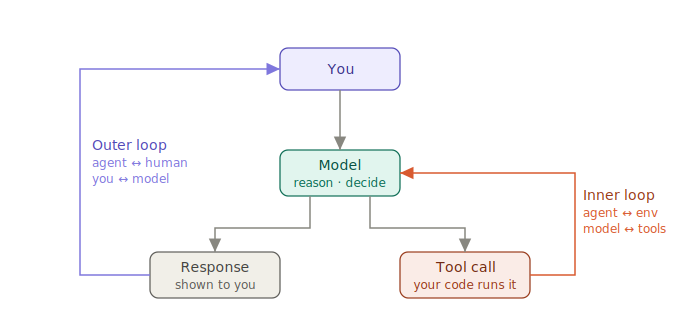

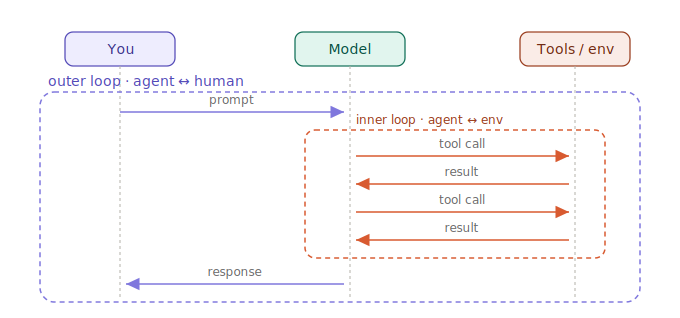

In [7]:
from IPython.display import SVG, display
display(SVG(filename="../figures/two_loops_flow.svg"))      # Form 1 - flow (above)
display(SVG(filename="../figures/two_loops_swimlane.svg"))  # Form 3 - swimlane (below)

## A0 — Setup & the Session 2 scaffold, carried forward

Two things carry over from Session 2, unchanged:

- `agentlib.tools.call(...) -> Result`, now also accepting `tools=`.
  - `Result` carries `.tool_calls` and `.output_items`.
- `chat_turn(history, msg)` and a `history` list, the by-hand multi-turn loop.
  - shipped as a single-turn function, not a REPL. Wrapping it in an input loop is new here.

In [1]:
from agentlib.tools import call, show, CHEAP, STRONG, MODELS
print("pinned models:", MODELS)

# A trivial call still works exactly as in S2.
r = call("Reply with exactly one word: ok", model=CHEAP, max_output_tokens=16)
show(r, "A0")
print("text:", repr(r.text))

pinned models: {'cheap': 'gpt-5.4-nano', 'strong': 'gpt-5.4'}
[A0] gpt-5.4-nano | in=13 (cached 0) out=5 (reasoning 0) | $0.000009 (0.0009¢) | status=completed
text: 'ok'


In [2]:
# The S2 carry-forward loop, verbatim. `history` is a plain list[dict]; that list IS the memory.
def chat_turn(history: list, user_msg: str, use_history: bool = True) -> str:
    convo = (history if use_history else []) + [{"role": "user", "content": user_msg}]
    reply = call(messages=convo, model=CHEAP, max_output_tokens=2000).text
    history.append({"role": "user", "content": user_msg})
    history.append({"role": "assistant", "content": reply})
    return reply

history = []
print("T1:", chat_turn(history, "I always pick a window seat, and I'm into sci-fi."))
print("T2:", chat_turn(history, "Which seat do I prefer, and what genre do I like?"))
print("history carries", len(history), "messages")

T1: Nice—window seat + sci‑fi is a great combo. 😄  

If you want to lean into that vibe, here are a few fun “window-seat sci‑fi” picks you might like:

- **Star Wars / Star Trek:** anything that feels like you’re watching hyperspace or scanning a starfield from the window.
- **The Expanse:** big, grounded space vibes—very “Earth to the void” energy.
- **Dune:** more atmospheric and desert‑myth, like the sand is outside your window and you’re plotting a longer journey.
- **Project Hail Mary (sci‑fi adventure):** fast, hopeful, very “something might happen at any moment” on a trip.

Quick question so I can tailor it: **Are you trying to choose an in‑flight movie/book, or are you describing what you like about flying?**
T2: You prefer a **window seat**, and you like the **science fiction (sci‑fi) genre**.
history carries 4 messages


## A1 — Tool calling, rung 1: the manual JSON protocol

Rung 1, the mechanic in the raw:
- the system prompt tells the model to emit JSON
- we parse and dispatch it by hand
- watch it work under a firm instruction

In [3]:
import json

def add(a, b):
    return a + b

# Constrain HARD: forbid prose, demand only the JSON. Rung 1 can work like this.
FIRM_SYS = (
    "You are a routing layer with NO ability to do arithmetic yourself. For any sum you "
    'MUST reply with ONLY this JSON object and nothing else: '
    '{"type":"tool_call","name":"add","arguments":{"a":<num>,"b":<num>}}'
)

def dispatch_strict(text):
    blob = json.loads(text)              # rung-1 parse: assumes the WHOLE reply is clean JSON
    if blob["name"] == "add":
        return add(**blob["arguments"])

r = call("What is 17 plus 23?", system=FIRM_SYS, model=CHEAP, max_output_tokens=120)
print("raw model text:", repr(r.text))
result = dispatch_strict(r.text)
print("dispatched result:", result, " <- YOUR code parsed the request and ran add().")
print("   In an agent, THIS value is what you feed back to the model on its NEXT turn")
print("   (the observe step) so it can carry on -- we wire that loop up in A3.")

raw model text: '{"type":"tool_call","name":"add","arguments":{"a":17,"b":23}}'
dispatched result: 40  <- YOUR code parsed the request and ran add().
   In an agent, THIS value is what you feed back to the model on its NEXT turn
   (the observe step) so it can carry on -- we wire that loop up in A3.


- It works only because we forbade prose and demanded clean JSON.
- Loosen the instruction to how a user really talks, and it often breaks.

In [5]:
# A natural, chatty instruction. Same tool, looser ask.
LIGHT_SYS = (
    "You can use a tool add(a, b). When the user needs a sum, emit a JSON object: "
    '{"type":"tool_call","name":"add","arguments":{"a":..,"b":..}}'
)
r2 = call("What is 17 plus 23? Walk me through it.", system=LIGHT_SYS, model=CHEAP, max_output_tokens=250)
print("raw model text:", repr(r2.text[:170]), "...\n")

# The same rung-1 strict parse, now on a reply the model decorated (or answered outright):
try:
    print("strict dispatch:", dispatch_strict(r2.text))
except (json.JSONDecodeError, KeyError, TypeError) as e:
    print("strict dispatch FAILED:", type(e).__name__, e)   # the fragility, live

raw model text: '{"type":"tool_call","name":"add","arguments":{"a":17,"b":23}}{"type":"tool_call","name":"add","arguments":{"a":17,"b":23}}' ...

strict dispatch FAILED: JSONDecodeError Extra data: line 1 column 62 (char 61)


The naive `json.loads(reply)` call routinely fails under a light instruction. The model:
- wraps the JSON in a walkthrough
- fences it
- or just answers in prose and skips the call

A defensive parse claws some of it back, but it's whack-a-mole. Rungs 2–3 replace that with structure the API enforces.

In [7]:
def first_json(text):
    # Find the first '{' and read exactly one object from there, ignoring trailing prose.
    i = text.find("{")
    if i == -1:
        raise ValueError("no JSON object in reply")
    return json.JSONDecoder().raw_decode(text, i)[0]

def dispatch_defensive(text):
    try:
        blob = first_json(text)
        return add(**blob["arguments"]) if blob.get("name") == "add" else ("UNKNOWN", blob)
    except Exception as e:
        return ("PARSE_FAILED", repr(e))   # e.g. the model skipped the call and just answered

print("defensive dispatch:", dispatch_defensive(r2.text), "  # recovers IF there was a call to find")

defensive dispatch: 40   # recovers IF there was a call to find


## A2 — Rung 2: a `Tool` wrapper / registry

- One consistent path for many tools: register each once, dispatch through a tiny registry.
- It still trusts the model's JSON to match each function's signature.
- Change `add` and nothing keeps them in sync.

In [8]:
def multiply(a, b):
    return a * b

# One registry; both tools dispatch through one uniform path.
REGISTRY = {"add": add, "multiply": multiply}

def dispatch_registry(text):
    blob = first_json(text)              # reuse the rung-1 defensive parser
    fn = REGISTRY.get(blob["name"])
    if fn is None:
        return ("UNKNOWN_TOOL", blob["name"])
    return fn(**blob["arguments"])

MULTI_SYS = (
    "You have tools: add(a, b), multiply(a, b). Reply with ONLY a JSON object: "
    '{"type":"tool_call","name":"<tool>","arguments":{"a":<num>,"b":<num>}}'
)
for q in ["add 12 and 30", "what is 6 times 7?"]:
    r = call(q, system=MULTI_SYS, model=CHEAP, max_output_tokens=120)
    print(f"{q!r:28} -> {dispatch_registry(r.text)}")

'add 12 and 30'              -> 42
'what is 6 times 7?'         -> 42


## A3 — Rung 3: auto-generate the schema, then let the provider drive tool calls

- Derive the schema from the function: name, typed params, docstring as description.
- Provider-native calling takes over, and the model emits a `function_call`.
- Your result must tie back to its `call_id`.

In [ ]:
import inspect

# Rung 3: the schema is DERIVED from the function — signature + annotations + docstring.
_PYTYPE = {int: "integer", float: "number", str: "string", bool: "boolean"}

def schema_for(fn):
    sig = inspect.signature(fn)
    props, required = {}, []
    for name, p in sig.parameters.items():
        props[name] = {"type": _PYTYPE.get(p.annotation, "string")}
        if p.default is inspect.Parameter.empty:
            required.append(name)
    return {
        "type": "function", "name": fn.__name__,
        "description": (fn.__doc__ or "").strip(),
        "parameters": {"type": "object", "properties": props,
                       "required": required, "additionalProperties": False},
    }

def add(a: float, b: float) -> float:
    '''Add exactly two numbers and return their sum. To total more than two numbers,
    call this repeatedly, two at a time.'''
    return a + b

import json
print(json.dumps(schema_for(add), indent=2))

{
  "type": "function",
  "name": "add",
  "description": "Add exactly two numbers and return their sum. To total more than two numbers,\ncall this repeatedly, two at a time.",
  "parameters": {
    "type": "object",
    "properties": {
      "a": {
        "type": "number"
      },
      "b": {
        "type": "number"
      }
    },
    "required": [
      "a",
      "b"
    ],
    "additionalProperties": false
  }
}


In [11]:
# The single-step round trip, by hand, with the PROVIDER-NATIVE tool call (no regex).
# We return the exchange as a list of (role, content) turns so the loop is VISIBLE.
ADD_SCHEMA = [schema_for(add)]

def one_step(user_msg):
    r = call(messages=[{"role": "user", "content": user_msg}], model=CHEAP, tools=ADD_SCHEMA)
    if not r.tool_calls:
        return [("user", user_msg), ("assistant", r.text)]
    tc = r.tool_calls[0]
    result = add(**tc["arguments"])                          # YOUR code runs the function
    msgs = [{"role": "user", "content": user_msg}]
    msgs += r.output_items                                   # the model's function_call item
    msgs.append({"type": "function_call_output",             # the result, tied to call_id
                 "call_id": tc["call_id"], "output": json.dumps({"result": result})})
    final = call(messages=msgs, model=CHEAP, tools=ADD_SCHEMA)
    return [("user", user_msg),
            ("assistant -> tool_call", f"{tc['name']}({tc['arguments']})"),
            ("tool_result -> model", result),
            ("assistant", final.text)]

def show_turns(turns):
    for role, content in turns:                              # one turn per line == the history
        print(f"  {role:24}: {content}")

# The model DECIDES: a fact it knows -> answers directly; arithmetic -> calls the tool.
print("Q: capital of Britain?")
show_turns(one_step("What's the capital of Britain?"))
print("\nQ: add 17 and 23?")
show_turns(one_step("Add 17 and 23 for me."))

Q: capital of Britain?
  user                    : What's the capital of Britain?
  assistant               : The capital of Britain is **London**.

Q: add 17 and 23?
  user                    : Add 17 and 23 for me.
  assistant -> tool_call  : add({'a': 17, 'b': 23})
  tool_result -> model    : 40
  assistant               : 17 + 23 = **40**.


## A4 — Tool availability ≠ tool competence: which tool gets called?

- Five overlapping "is it on my watchlist?" finders, one question.
- Watch which tool the model picks.
- Watch whether one clean run can be trusted.

In [13]:
from collections import Counter

def finder(name, desc):
    # Five near-SYNONYM finders: identical signature, only the name + description differ.
    return {"type": "function", "name": name, "description": desc,
            "parameters": {"type": "object", "properties": {"query": {"type": "string"}},
                           "required": ["query"], "additionalProperties": False}}

FINDERS = [
    finder("check_watchlist", "Check the watchlist for a given item."),
    finder("search_titles",   "Search saved titles for a match."),
    finder("find_on_list",    "Find whether an item is on the user's list."),
    finder("lookup_saved",    "Look up an item among the saved entries."),
    finder("scan_library",    "Scan the media library for a match."),
]
ASK = "Do I already have Project Hail Mary saved?"

def tool_histogram(tools, prompt, k=20):
    # Fire the SAME prompt k times; tally which tool the model calls first.
    picks = Counter()
    for _ in range(k):
        r = call(messages=[{"role": "user", "content": prompt}], model=CHEAP, tools=tools)
        picks[r.tool_calls[0]["name"] if r.tool_calls else "(answered, no call)"] += 1
    for name, n in picks.most_common():
        print(f"    {name:20} {n:2}/{k}  {'#' * n}")
    return picks

print("ORDER A -- the five tools exactly as listed:")
_ = tool_histogram(FINDERS, ASK)

ORDER A -- the five tools exactly as listed:
    find_on_list         20/20  ####################


- One tool took almost every call, the kind of green run you'd ship on.
- Now change nothing but the order we hand the tools to the model.

In [14]:
print("ORDER B -- the SAME five tools, reversed:")
_ = tool_histogram(list(reversed(FINDERS)), ASK)

ORDER B -- the SAME five tools, reversed:
    find_on_list         14/20  ##############
    lookup_saved          5/20  #####
    check_watchlist       1/20  #


- The choice scattered across several tools, and the winner moved.
- Only the order changed: list position decided which tool fired.

- The fix lives in the description.
- Give the tool that owns this intent a decisive when-to-use line.
- Leave the others vague, and re-run both orderings.

In [15]:
FINDERS_FIXED = [
    finder("check_watchlist",
           "Check whether a specific title is already on the user's watchlist. This is the "
           "correct tool for 'do I already have X?' membership questions -- prefer it over "
           "the other search tools."),                       # <- the ONLY line that changed
    finder("search_titles", "Search saved titles for a match."),
    finder("find_on_list",  "Find whether an item is on the user's list."),
    finder("lookup_saved",  "Look up an item among the saved entries."),
    finder("scan_library",  "Scan the media library for a match."),
]
print("FIXED, ORDER A (sharpened tool first):")
_ = tool_histogram(FINDERS_FIXED, ASK)
print("FIXED, ORDER B (sharpened tool LAST):")
_ = tool_histogram(list(reversed(FINDERS_FIXED)), ASK)

FIXED, ORDER A (sharpened tool first):
    check_watchlist      20/20  ####################
FIXED, ORDER B (sharpened tool LAST):
    check_watchlist      20/20  ####################


- `check_watchlist` now wins in both orders: one line of description beat position.

> Past a few dozen tools, descriptions alone stop scaling: selection degrades and definitions bloat the context. Overlapping tools are a liability.

## A5 — The loop: observe → reason → act → verify (and the stopping condition)

- Wrap the round trip in a loop the model drives.
- Below: the loop uncapped, then the same loop with a max-step cap.
- This loop is the heart of the course project.

In [16]:

def run_agent(user_msg, schemas, tools, model=CHEAP, max_steps=None, verbose=True):
    messages = [{"role": "user", "content": user_msg}]
    step = 0
    while True:
        r = call(messages=messages, model=model, tools=schemas)
        if not r.tool_calls:                              # the model chose to ANSWER -> done
            return {"answer": r.text, "steps": step, "stopped": "answered"}
        messages += r.output_items                        # append the model's tool-call item(s)
        for tc in r.tool_calls:                           # ACT: run each call, append its result
            out = tools[tc["name"]](**tc["arguments"])
            if verbose:
                print(f"  step {step+1}: {tc['name']}({tc['arguments']}) -> {out}")
            messages.append({"type": "function_call_output",
                             "call_id": tc["call_id"], "output": json.dumps({"result": out})})
        step += 1
        if max_steps is not None and step >= max_steps:   # the stopping condition
            return {"answer": None, "steps": step, "stopped": "max_steps"}

- `add` takes only two numbers, so a multi-term sum forces the model to chain calls.
- The loop visibly iterates.
- Run it uncapped first: the model decides each call until done.

In [17]:
def add(a: float, b: float) -> float:
    '''Add exactly two numbers and return their sum. To total more than two numbers,
    call this repeatedly, two at a time.'''
    return a + b

ADD = [schema_for(add)]
print("UNCAPPED — the model chains add calls until done:")
res = run_agent("What is 12 + 47 + 89 + 23 + 56 + 8? Use the add tool, two numbers at a time.",
                ADD, {"add": add})
print("answer:", res["answer"], "| steps:", res["steps"], "| stopped:", res["stopped"])

UNCAPPED — the model chains add calls until done:
  step 1: add({'a': 12, 'b': 47}) -> 59
  step 2: add({'a': 59, 'b': 89}) -> 148
  step 3: add({'a': 148, 'b': 23}) -> 171
  step 4: add({'a': 171, 'b': 56}) -> 227
  step 5: add({'a': 227, 'b': 8}) -> 235
answer: Using the add tool two numbers at a time:

12 + 47 = 59  
59 + 89 = 148  
148 + 23 = 171  
171 + 56 = 227  
227 + 8 = **235**

**Answer: 235** | steps: 5 | stopped: answered


- Now add the max-step cap: the same loop, given a ceiling.
- Stopping is now your code's decision, not the model's.

In [18]:
print("CAPPED at 2 steps — cut off cleanly:")
res = run_agent("What is 12 + 47 + 89 + 23 + 56 + 8? Use the add tool, two numbers at a time.",
                ADD, {"add": add}, max_steps=2)
print("answer:", res["answer"], "| steps:", res["steps"], "| stopped:", res["stopped"])
print("'It stopped' is now YOUR decision, not the model's. That is the guardrail (Part B).")

CAPPED at 2 steps — cut off cleanly:
  step 1: add({'a': 12, 'b': 47}) -> 59
  step 2: add({'a': 59, 'b': 89}) -> 148
answer: None | steps: 2 | stopped: max_steps
'It stopped' is now YOUR decision, not the model's. That is the guardrail (Part B).


## A6 — Your first agent: two tools that compose

- The real scaffold every later session extends: a JSON watchlist store alongside `add`.
- They compose: total a backlog's runtime by chaining `list_watchlist`, then `add`.
- One file, three functions, no database.

In [19]:
import os
WATCHLIST = "watchlist.json"
if os.path.exists(WATCHLIST):
    os.remove(WATCHLIST)                  # start fresh for a clean demo

def _load():
    return json.load(open(WATCHLIST)) if os.path.exists(WATCHLIST) else []
def _save(items):
    json.dump(items, open(WATCHLIST, "w"), indent=2)

def save_to_watchlist(title: str, kind: str, runtime_min: int) -> dict:
    '''Add an item to the watchlist. kind is one of movie/show/game; runtime_min is the
    length in minutes. Use when the user wants to remember something to watch or play.'''
    items = _load()
    item = {"id": (max([i["id"] for i in items]) + 1 if items else 1),
            "title": title, "kind": kind, "runtime_min": runtime_min}
    items.append(item); _save(items)
    return item

def list_watchlist() -> list:
    '''List every item on the watchlist with id, title, kind and runtime_min. Use when the
    user asks what is on their list or wants to total runtimes.'''
    return _load()

def remove_from_watchlist(item_id: int) -> dict:
    '''Permanently remove an item from the watchlist by its id. This cannot be undone.
    Use only after the user has explicitly confirmed the removal.'''
    keep = [i for i in _load() if i["id"] != item_id]
    _save(keep)
    return {"removed": item_id, "remaining": len(keep)}

# Seed three items so the total is real (114 + 60 + 90 = 264).
for t, k, m in [("Project Hail Mary", "movie", 114), ("Pluribus", "show", 60),
                ("Untitled Goose Game", "game", 90)]:
    save_to_watchlist(t, k, m)

TOOLS = [schema_for(save_to_watchlist), schema_for(list_watchlist),
         schema_for(remove_from_watchlist), schema_for(add)]
REG = {"save_to_watchlist": save_to_watchlist, "list_watchlist": list_watchlist,
       "remove_from_watchlist": remove_from_watchlist, "add": add}
print("seeded:", list_watchlist())

seeded: [{'id': 1, 'title': 'Project Hail Mary', 'kind': 'movie', 'runtime_min': 114}, {'id': 2, 'title': 'Pluribus', 'kind': 'show', 'runtime_min': 60}, {'id': 3, 'title': 'Untitled Goose Game', 'kind': 'game', 'runtime_min': 90}]


- Ask for the total runtime.
- The agent chains `list_watchlist`, then `add` across the runtimes, then answers.
- Watch the loop iterate.

In [21]:
res = run_agent("What's the total runtime of everything on my watchlist? ",
                TOOLS, REG, max_steps=8)
print("answer:", res["answer"], "| steps:", res["steps"])

  step 1: list_watchlist({}) -> [{'id': 1, 'title': 'Project Hail Mary', 'kind': 'movie', 'runtime_min': 114}, {'id': 2, 'title': 'Pluribus', 'kind': 'show', 'runtime_min': 60}, {'id': 3, 'title': 'Untitled Goose Game', 'kind': 'game', 'runtime_min': 90}]
  step 2: add({'a': 114, 'b': 60}) -> 174
  step 3: add({'a': 174, 'b': 90}) -> 264
answer: The total runtime of everything on your watchlist is **264 minutes**. | steps: 3


The bet: add a movie, then ask which item on the list is longest.
- Will the agent answer from the item it just added, or re-read the whole list first?
- The habit: after you change state, re-read it rather than trust the model's memory.

In [23]:
res = run_agent("Add The Odyssey (139 min, movie) to my watchlist", TOOLS, REG, max_steps=8)
print("answer:", res["answer"], "| steps:", res["steps"])
print("watchlist now:", [i['title'] for i in list_watchlist()])

  step 1: save_to_watchlist({'title': 'The Odyssey', 'kind': 'movie', 'runtime_min': 139}) -> {'id': 5, 'title': 'The Odyssey', 'kind': 'movie', 'runtime_min': 139}
answer: Added **The Odyssey** (139 min, movie) to your watchlist. | steps: 1
watchlist now: ['Project Hail Mary', 'Pluribus', 'Untitled Goose Game', 'The Odyssey', 'The Odyssey']


## Save this code — it's your course project

- This scaffold is the agent you evolve all course: `call()`, the registry, the loop, two composing tools, a max-step cap.
- Save and commit it. Every homework extends this code.
- Part B makes it safe: guardrails, the silent-error failure, a gate on `remove_from_watchlist`.